<a href="https://colab.research.google.com/github/ZoryAce/Topicos/blob/main/ENTREGA2/TALLER3/TallerE3_SongEmbeddingsVisualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


**TALLER No. 3 **

**INTEGRANTES:**

Luis Alejandro Garzón Ramirez

Yulieth Danitza Aguillón Ortega

Zorayda Acevedo Jiménez



## Song Embeddings - Skipgram Recommender

In this notebook, we'll use human-made music playlists to learn song embeddings. We'll treat a playlist as if it's a sentence and the songs it contains as words. We feed that to the word2vec algorithm which then learns embeddings for every song we have. These embeddings can then be used to recommend similar songs. This technique is used by Spotify, AirBnB, Alibaba, and others. It accounts for a vast portion of their user activity, user media consumption, and/or sales (in the case of Alibaba).

The [dataset we'll use](https://www.cs.cornell.edu/~shuochen/lme/data_page.html) was collected by Shuo Chen from Cornell University. The dataset contains playlists from hundreds of radio stations from around the US.

En este cuaderno, usaremos listas de reproducción de música creadas por personas para aprender incrustaciones de canciones. Trataremos cada lista de reproducción como si fuera una oración y las canciones que contiene como palabras. Alimentaremos esto al algoritmo word2vec, que luego aprende incrustaciones para cada canción que tenemos. Estas incrustaciones se pueden usar para recomendar canciones similares. Esta técnica es utilizada por Spotify, Airbnb, Alibaba y otros. Representa una gran parte de la actividad de sus usuarios, el consumo de medios de los usuarios y/o las ventas (en el caso de Alibaba).

El conjunto de datos que utilizaremos fue recopilado por Shuo Chen, de la Universidad de Cornell. Contiene listas de reproducción de cientos de emisoras de radio de todo Estados Unidos.

## Importing packages and dataset

In [35]:
!pip install gensim
!pip install numpy==1.25.2
import numpy as np
import pandas as pd
import gensim
from gensim.models import Word2Vec
from urllib import request
import warnings
warnings.filterwarnings('ignore')

El conjunto de datos de la lista de reproducción es un archivo de texto donde cada línea representa una lista de reproducción. Esta lista de reproducción es básicamente una serie de ID de canciones.

In [36]:
# Get the playlist dataset file
data = request.urlopen('https://storage.googleapis.com/maps-premium/dataset/yes_complete/train.txt')

# Parse the playlist dataset file. Skip the first two lines as
# they only contain metadata
lines = data.read().decode("utf-8").split('\n')[2:]

# Remove playlists with only one song
playlists = [s.rstrip().split() for s in lines if len(s.split()) > 1]


La variable playlists ahora contiene una lista de Python. Cada elemento de esta lista es una lista de reproducción que contiene los identificadores de las canciones. Podemos ver las dos primeras listas de reproducción aquí:

In [37]:
print( 'Playlist #1:\n ', playlists[0], '\n')
print( 'Playlist #2:\n ', playlists[1])

Playlist #1:
  ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '2', '42', '43', '44', '45', '46', '47', '48', '20', '49', '8', '50', '51', '52', '53', '54', '55', '56', '57', '25', '58', '59', '60', '61', '62', '3', '63', '64', '65', '66', '46', '47', '67', '2', '48', '68', '69', '70', '57', '50', '71', '72', '53', '73', '25', '74', '59', '20', '46', '75', '76', '77', '59', '20', '43'] 

Playlist #2:
  ['78', '79', '80', '3', '62', '81', '14', '82', '48', '83', '84', '17', '85', '86', '87', '88', '74', '89', '90', '91', '4', '73', '62', '92', '17', '53', '59', '93', '94', '51', '50', '27', '95', '48', '96', '97', '98', '99', '100', '57', '101', '102', '25', '103', '3', '104', '105', '106', '107', '47', '108', '109', '110', '111', '112', '113', '25', '63', '62', '114', '115', '84', '116', '117',

## Training the Word2Vec Model
Nuestro conjunto de datos ahora tiene la forma que el modelo Word2Vec espera como entrada. Pasamos el conjunto de datos al modelo.

In [38]:
model = Word2Vec(playlists, vector_size=32, window=20, negative=50, min_count=1, workers=4)

El modelo ya está entrenado. Cada canción tiene una incrustación. Solo tenemos los identificadores de las canciones, sin títulos ni otra información. Vamos a obtener el archivo de información de la canción.

# Parametros de Word2Vec

vector_size=32  Defina el número de dimensiones del vector que representará cada palabra o elemento.  Un valor pequeño como 32 reduce el tamaño del modelo pero puede limitar la capacidad de captar significados complejos.

window=20  Es el tamaño de la ventana de contexto , que define cuántas palabras (o elementos) a la izquierda y derecha se consideran para establecer relaciones. En este caso, el modelo mirará hasta 20 elementos antes y después de la palabra objetivo.  Un valor grande como 20es típico en datos secuenciales como listas de reproducción, donde el orden importa mucho.

negative=50  Es el número de ejemplos negativos que se generan para cada ejemplo positivo durante el entrenamiento.  En Negative Sampling , el modelo aprende mejor al distinguir entre palabras reales del contexto y palabras aleatorias (negativas).  Un valor alto como 50 se usa para grandes conjuntos de datos donde hay muchas palabras irrelevantes.

min_count=1  Establece el umbral mínimo de apariciones para que una palabra sea considerada en el vocabulario.

min_count=1  significa que incluso palabras que aparecen una sola vez se incluyen en el modelo. Esto es ideal para conjuntos de datos pequeños o donde cada elemento es importante (como canciones en una lista de reproducción).

workers=4  Controla el número de hilos que se usarán durante el entrenamiento para acelerar el proceso.  Un valor como 4permite aprovechar CPU con múltiples núcleos.

## Song Title and Artist File
Let's load and parse the file containing song titles and artists

Carguemos y analicemos el archivo que contiene los títulos y artistas de las canciones.

In [39]:
songs_file = request.urlopen('https://storage.googleapis.com/maps-premium/dataset/yes_complete/song_hash.txt')
songs_file = songs_file.read().decode("utf-8").split('\n')
songs = [s.rstrip().split('\t') for s in songs_file]

In [40]:
songs_df = pd.DataFrame(data=songs, columns = ['id', 'title', 'artist'])
songs_df = songs_df.set_index('id')

In [41]:
songs_df.head()

,title,artist
id,,
0,Gucci Time (w\/ Swizz Beatz),Gucci Mane
1,Aston Martin Music (w\/ Drake & Chrisette Mich...,Rick Ross
2,Get Back Up (w\/ Chris Brown),T.I.
3,Hot Toddy (w\/ Jay-Z & Ester Dean),Usher
4,Whip My Hair,Willow


In [42]:
songs_df.shape

(75263, 2)

### Exercise:

Build visualization for the embeddings of the song recommender.
Generemos una visualización para las incrustaciones del recomendador de canciones.



Selección de las 5 canciones que mas se repiten en el dataset

In [43]:
from collections import Counter

# Aplanar la lista de playlists en una sola lista de canciones
all_songs = [song for playlist in playlists for song in playlist]

# Contar la frecuencia de cada canción
song_counts = Counter(all_songs)

# Obtener las 5 canciones más comunes
most_common_songs = song_counts.most_common(5)

# Imprimir las canciones más comunes y sus frecuencias
for song_id, frequency in most_common_songs:
    print(f"Canción ID: {song_id}, Frecuencia: {frequency}")

Canción ID: 20065, Frecuencia: 5593
Canción ID: 5, Frecuencia: 5041
Canción ID: 46, Frecuencia: 4497
Canción ID: 7233, Frecuencia: 3828
Canción ID: 20627, Frecuencia: 3767


In [44]:
row_indices = [5, 46, 7233, 20065, 20627]
songs_df.iloc[row_indices]

,title,artist
id,,
5,Down On Me (w\/ 50 Cent),Jeremih
46,What's My Name (w\/ Drake),Rihanna
7233,Grenade,Bruno Mars
20065,Moment 4 Life (w\/ Drake),Nicki Minaj
20627,Look At Me Now (w\/ Lil Wayne & Busta Rhymes),Chris Brown


In [45]:
# Definir los IDs de canciones de interés
keys = ['5', '46', '7233', '20065', '20627']

# Usar comprensión de listas para simplificar el código
embedding_clusters = [
    [model.wv[similar_word] for similar_word, _ in model.wv.most_similar(word, topn=30)]
    for word in keys
]

word_clusters = [
    [similar_word for similar_word, _ in model.wv.most_similar(word, topn=30)]
    for word in keys
]

In [46]:
#Reducción de dimensionalidad
from sklearn.manifold import TSNE
import numpy as np

embedding_clusters = np.array(embedding_clusters)

# Obtener las dimensiones del array: n = número de palabras clave (o clusters),
#m = número de palabras similares, k = dimensiones del embedding
n, m, k = embedding_clusters.shape

# Inicializar el modelo t-SNE con las configuraciones dadas
tsne_model_en_2d = TSNE(perplexity=50, n_components=2, init='pca', n_iter=1500, random_state=920311)

# Aplicar t-SNE a los embeddings:
embeddings_en_2d = np.array(tsne_model_en_2d.fit_transform(embedding_clusters.reshape(n * m, k))).reshape(n, m, 2)

In [47]:
#Mostrar nombres de canciones y artista
# Formateo de indices
songs_df.index = songs_df.index.astype(str).str.strip()

# Reemplazar los IDs de canciones por "título - artista"
word_clusters_named = [
    [f"{songs_df.loc[song_id]['title']} - {songs_df.loc[song_id]['artist']}" if song_id in songs_df.index else song_id
     for song_id in cluster]
    for cluster in word_clusters
]

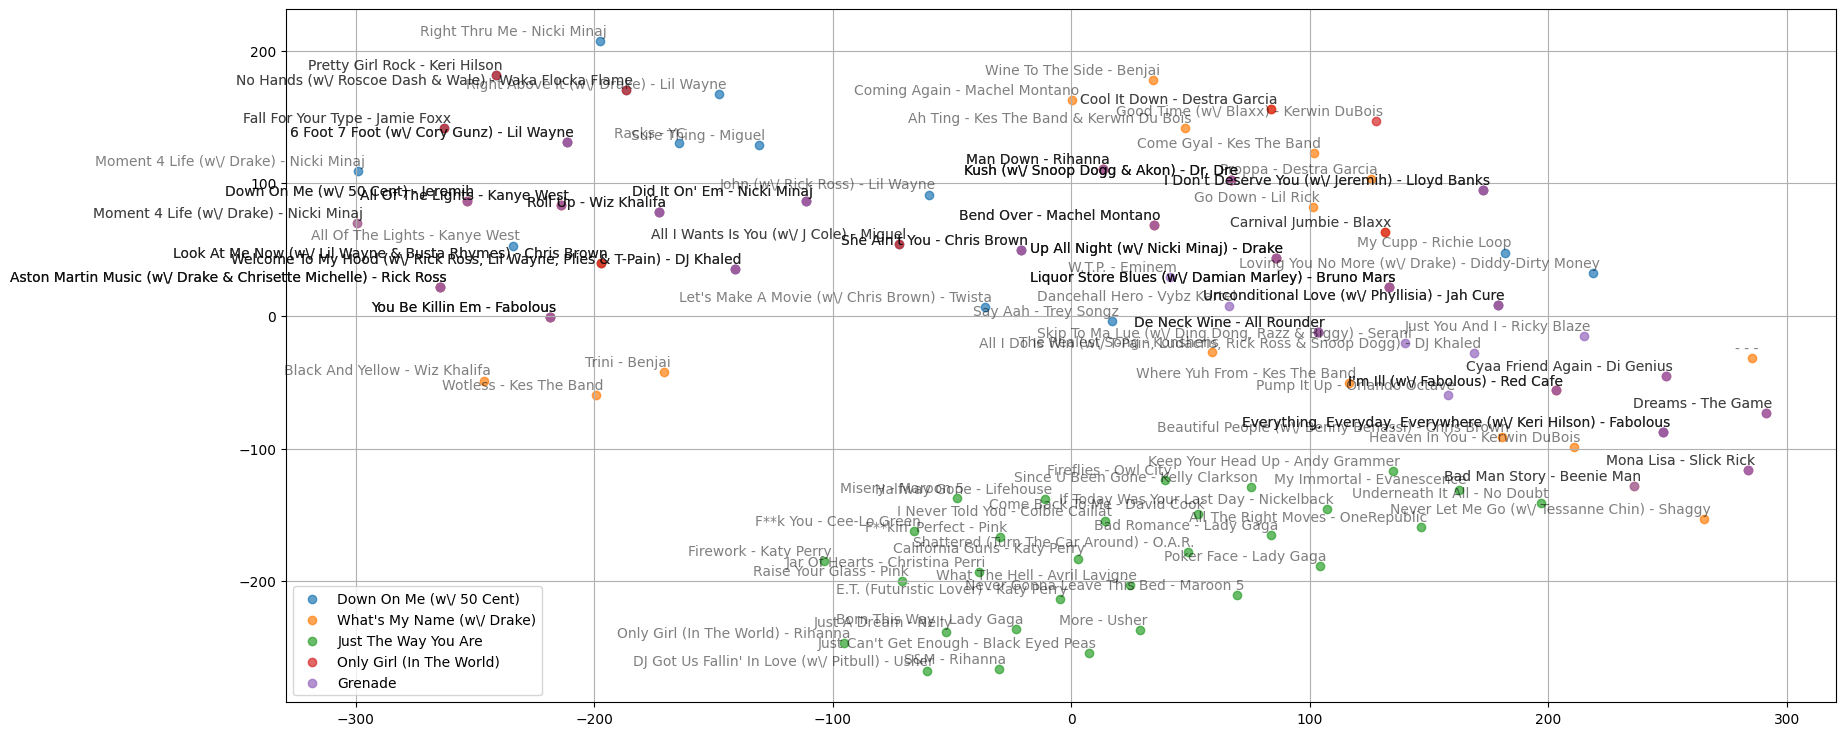

In [48]:
#Graficar clusters
import matplotlib.pyplot as plt
import matplotlib.cm as cm
%matplotlib inline

# Función para crear gráficos 2D de embeddings usando Matplotlib
def tsne_plot_similar_words(labels, embedding_clusters, word_clusters, a=0.7):
    plt.figure(figsize=(20, 9))

    # Iterar sobre cada conjunto de etiquetas, embeddings y palabras
    for label, embeddings, words in zip(labels, embedding_clusters, word_clusters):
        x = embeddings[:, 0]  # Coordenada X
        y = embeddings[:, 1]  # Coordenada Y
        plt.scatter(x, y, alpha=a, label=label)  # Graficar los puntos
        # Anotar cada punto con la palabra correspondiente
        for i, word in enumerate(words):
            plt.annotate(word, alpha=0.5, xy=(x[i], y[i]), xytext=(5, 2),
                         textcoords='offset points', ha='right', va='bottom', size=10)

    plt.legend(loc=3)
    plt.grid(True)
    plt.show()

# Definir etiquetas para los clusters
song_titles = ["Down On Me (w\/ 50 Cent)", "What's My Name (w\/ Drake)", "Just The Way You Are", "Only Girl (In The World)", "Grenade", "Firework", "6 Foot 7 Foot (w\/ Cory Gunz)", "Moment 4 Life (w\/ Drake)", "All Of The Lights", "Look At Me Now (w\/ Lil Wayne & Busta Rhymes)" ]

# función para generar el gráfico con las nuevas etiquetas
tsne_plot_similar_words(song_titles, embeddings_en_2d, word_clusters_named)

In [50]:
songs_df.index = pd.to_numeric(songs_df.index, errors='coerce')
songs_df = songs_df[songs_df.index.notna()]
songs_df.index = songs_df.index.astype(int)

In [51]:
#Extraer los primeros elementos de cada sublista
song_ids = []
for s in songs:
    try:
        song_id = int(s[0].strip())
        song_ids.append(song_id)
    except ValueError:
        print(f"Skipping invalid song ID: {s[0]}")
print(songs_df[songs_df.index.isin(song_ids)][['title', 'artist']].head(5))

Skipping invalid song ID: 
                                                title      artist
id                                                               
0                        Gucci Time (w\/ Swizz Beatz)  Gucci Mane
1   Aston Martin Music (w\/ Drake & Chrisette Mich...   Rick Ross
2                       Get Back Up (w\/ Chris Brown)        T.I.
3                  Hot Toddy (w\/ Jay-Z & Ester Dean)       Usher
4                                        Whip My Hair      Willow


In [52]:
#Imprimir los 5 clusters de canciones
for i, songs in enumerate(word_clusters):
    print(f"\n🎵 Cluster {i + 1}")

    # Limpiar los IDs y convertirlos a enteros válidos
    song_ids = [int(s.strip()) for s in songs if s.strip().isdigit()]

    # Verificar si hay canciones válidas
    if song_ids:
        print(songs_df.loc[songs_df.index.isin(song_ids)][['title', 'artist']].head(10))


🎵 Cluster 1
                                                 title       artist
id                                                                 
1    Aston Martin Music (w\/ Drake & Chrisette Mich...    Rick Ross
11                                             My Cupp  Richie Loop
17                     All I Wants Is You (w\/ J Cole)       Miguel
25                                       Right Thru Me  Nicki Minaj
53                      Up All Night (w\/ Nicki Minaj)        Drake
57              Liquor Store Blues (w\/ Damian Marley)   Bruno Mars
77                                    You Be Killin Em     Fabolous
99   Everything, Everyday, Everywhere (w\/ Keri Hil...     Fabolous
225                                            Say Aah   Trey Songz
242                         Right Above It (w\/ Drake)    Lil Wayne

🎵 Cluster 2
                                                   title       artist
id                                                                   
1      Aston Marti

RESULTADOS:

-Agrupaciones densas: muchas canciones similares fueron encontradas para cada canción clave.

-Canciones que aparecen en más de un cluster: canciones como "Down On Me" o "Aston Martin Music" repetidas en distintos grupos indica que estas canciones son versátiles, aparecen en muchos contextos, por lo que hace suponer que puede que estén relacionadas con múltiples géneros, moods o estilos.

-Clusters que se solapan: las canciones clave de esos clusters se parecen mucho entre sí.